
========== DATA INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 9 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Name of State / UT                                       33 non-null     object 
 1   Total Confirmed cases (Including 76 foreign Nationals)   33 non-null     int64  
 2   Cured/Discharged/Migrated                                33 non-null     int64  
 3   Death                                                    33 non-null     int64  
 4   Date                                                     33 non-null     object 
 5   Latitude                                                 33 non-null     float64
 6   Longitude                                                33 non-null     float64
 7   Total cases                                              33 non-null     int64  
 8   

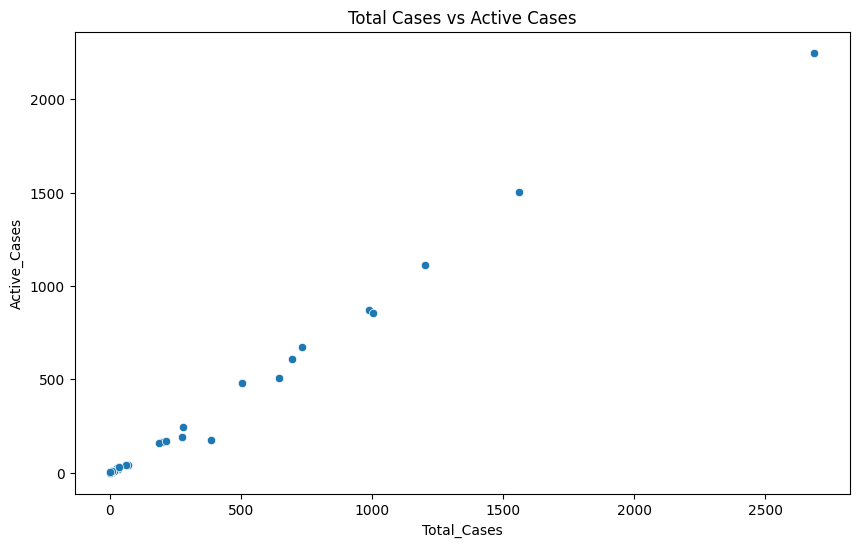

Insight:
There is a clear positive correlation: as total cases increases, active cases also increase.


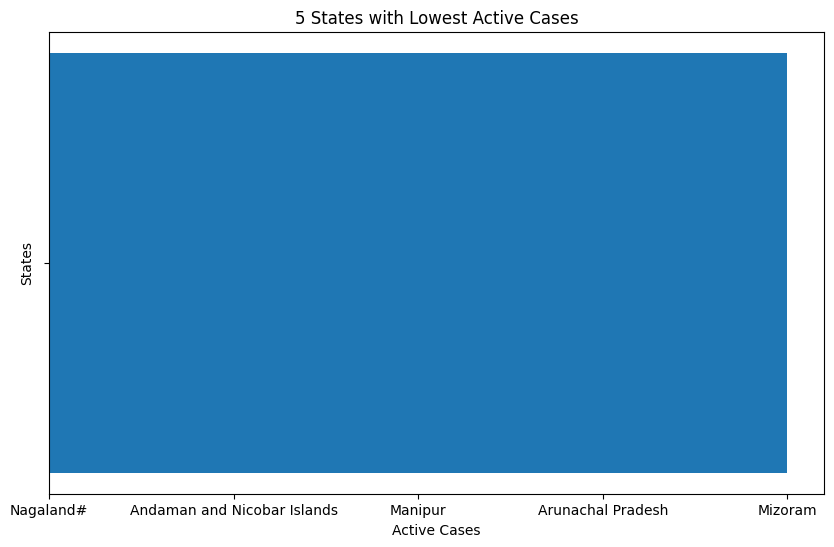

Insight:
Lowest active cases indicate better control and faster recovery.

========== Conclusion ==========
This project shows how COVID-19 cases vary across states,
 highlighting differences in active, recovered, and death cases.
It helps identify the most and least affected states and shows a 
positive relation between total and active cases.


In [2]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

df = pd.read_csv("state_wise_data.csv")

# 3. Data Inspection

print("\n========== DATA INFO ==========")
df.info()

print("\n=========== Shape (Rows, Columns) ============")
print(df.shape)

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe(include='all'))

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== LAST 5 ROWS ==========")
print(df.tail())

print("\n========== Number of Rows ==========")
print(len(df))

print("\n========== Column Names ===========")
print(df.columns.tolist())

# 4. Data Cleaning

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print(df.duplicated().sum())

# Rename Columns

df.rename(columns={
    'Name of State / UT': 'State',
    'Total Confirmed cases (Including 76 foreign Nationals)': 'Confirmed_Cases',
    'Cured/Discharged/Migrated': 'Recovered',
    'Death': 'Deaths',
    'Total cases': 'Total_Cases',
    'Active cases': 'Active_Cases'
}, inplace=True)

print("\n========== UPDATED COLUMN NAMES ==========")
print(df.columns.tolist())

# ANALYTICAL QUESTIONS

# Q1. Which 5 states/UTs have the highest number of active COVID-19 cases?

top_active = df.nlargest(5, 'Active_Cases')
print("\n",top_active[['State', 'Active_Cases']])
print("Insight:")
print("These states currently have the highest number of active COVID-19 cases.")

# Q2. Which 5 states/UTs have reported the highest number of deaths?

top_deaths = df.nlargest(5, 'Deaths')
print("\n",top_deaths[['State', 'Deaths']])
print("Insight:")
print("These states have recorded the highest COVID-19 death counts.")

# Q3. Which state has the highest recovery count?

highest_recovery = df.loc[df['Recovered'].idxmax()]
print("\nState:", highest_recovery['State'])
print("Recovery Count:", highest_recovery['Recovered'])
print("Insight:")
print(f"{highest_recovery['State']} has the highest recovery count with {highest_recovery['Recovered']} recovered/discharged cases.")

# Q4. What is the ralationship between total cases and active cases across states?

plt.figure(figsize=(10,6))
sns.scatterplot(x='Total_Cases', y='Active_Cases', data=df)
plt.title("Total Cases vs Active Cases")
plt.show()
print("Insight:")
print("There is a clear positive correlation: as total cases increases, active cases also increase.")

# Q5. Which 5 states have the lowest active cases?

lowest_5 = df.sort_values(by='Active_Cases', ascending=True).head(5)
plt.figure(figsize=(10,6))
plt.barh("\n",lowest_5['State'], lowest_5['Active_Cases'])
plt.xlabel("Active Cases")
plt.ylabel("States")
plt.title("5 States with Lowest Active Cases")
plt.show()
print("Insight:")
print("Lowest active cases indicate better control and faster recovery.")

print("\n========== Conclusion ==========")
print("This project shows how COVID-19 cases vary across states,")
print(" highlighting differences in active, recovered, and death cases.")
print("It helps identify the most and least affected states and shows a ")
print("positive relation between total and active cases.")